<a href="https://colab.research.google.com/github/Dulyana-Silva/MLproject6-Stock-Trend-Prediction/blob/main/Stock_Trend_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

In [36]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2026, 6, 1)

df = yf.download(stock, start, end)

/tmp/ipykernel_735/1347634669.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [37]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,30.896236,33.629602,25.536998,27.579345,855215656
2007-10-08,29.314573,31.940446,29.130301,31.940446,126671715
2007-10-09,31.310860,31.587267,27.748271,29.329936,116725709
2007-10-10,31.602602,32.247554,31.326195,32.124705,67931378
2007-10-11,35.134487,36.854358,31.326205,36.854358,106320954


Data is starting from **2007**.

We asked for data from 2000, since it gave starting from 2007, that's means yfinance only has data from 2007.

In [38]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2026-05-25,295.350006,298.500000,294.149994,298.500000,5896815
2026-05-26,292.549988,295.950012,292.049988,295.000000,5625947
2026-05-27,300.149994,301.250000,292.000000,292.000000,9883025
2026-05-28,300.149994,300.149994,300.149994,300.149994,0
2026-05-29,290.549988,303.000000,285.450012,303.000000,77407363


In [39]:
df.shape

(4598, 5)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4598 entries, 2007-10-05 to 2026-05-29
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4598 non-null   float64
 1   (High, POWERGRID.NS)    4598 non-null   float64
 2   (Low, POWERGRID.NS)     4598 non-null   float64
 3   (Open, POWERGRID.NS)    4598 non-null   float64
 4   (Volume, POWERGRID.NS)  4598 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 215.5 KB


In [41]:
df.isnull().sum()

,,0
Price,Ticker,
Close,POWERGRID.NS,0
High,POWERGRID.NS,0
Low,POWERGRID.NS,0
Open,POWERGRID.NS,0
Volume,POWERGRID.NS,0


There's No any null values.

In [42]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4598.000000,4598.000000,4598.000000,4598.000000,4.598000e+03
mean,93.773844,94.943077,92.618616,93.821073,1.199055e+07
std,83.032255,83.943007,82.093907,83.050471,1.984763e+07
min,18.038849,19.282907,16.172761,19.189602,0.000000e+00
25%,35.328309,35.849248,34.828865,35.379366,5.030466e+06
50%,65.839470,66.743185,64.921291,65.924906,8.693871e+06
75%,109.070290,111.024434,107.576961,109.063493,1.391070e+07
max,344.843262,345.598137,337.058457,343.522181,8.552157e+08


In [43]:
# Adding the index column
df = df.reset_index()

In [44]:
# New number of colums --> 6
df.shape

(4598, 6)

In [45]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,2007-10-05,30.896236,33.629602,25.536998,27.579345,855215656
1,2007-10-08,29.314573,31.940446,29.130301,31.940446,126671715
2,2007-10-09,31.310860,31.587267,27.748271,29.329936,116725709
3,2007-10-10,31.602602,32.247554,31.326195,32.124705,67931378
4,2007-10-11,35.134487,36.854358,31.326205,36.854358,106320954


Now the index column is visible.

In [46]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [58]:
#candlesticks --> Type of price chart used in technical analysis.
import plotly.graph_objects as go

fig = go.Figure(data = [go.Candlestick(x = df['Date'], open= df['Open'], high = df['High'], low=df['Low'], close = df['Close'])])

fig.update_layout(xaxis_rangeslider_visible = False)

fig.show()

In [53]:
data01 = df.to_csv("powergrid.csv")

In [54]:
data01 = pd.read_csv("powergrid.csv")

In [55]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.896236419677734,33.62960189509571,25.536998153531204,27.579344583114715,855215656
2,1,2007-10-08,29.314573287963867,31.940446244514217,29.13030069765617,31.940446244514217,126671715
3,2,2007-10-09,31.31085968017578,31.587266562499465,27.74827051473354,29.32993605329764,116725709
4,3,2007-10-10,31.602602005004883,32.24755374642532,31.326195305988854,32.12470470469476,67931378


**Now it's a one DataFrame.**

In [59]:
#candlesticks --> Type of price chart used in technical analysis.
import plotly.graph_objects as go

fig = go.Figure(data = [go.Candlestick(x = data01['Date'], open= data01['Open'], high = data01['High'], low=data01['Low'], close = data01['Close'])])

fig.update_layout(xaxis_rangeslider_visible = False)

fig.show()

Now we got the **Candlestick plot.**

In [60]:
df = df.drop(['Date'], axis = 1)

/tmp/ipykernel_735/1002300862.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



In [61]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,30.896236,33.629602,25.536998,27.579345,855215656
1,29.314573,31.940446,29.130301,31.940446,126671715
2,31.310860,31.587267,27.748271,29.329936,116725709
3,31.602602,32.247554,31.326195,32.124705,67931378
4,35.134487,36.854358,31.326205,36.854358,106320954


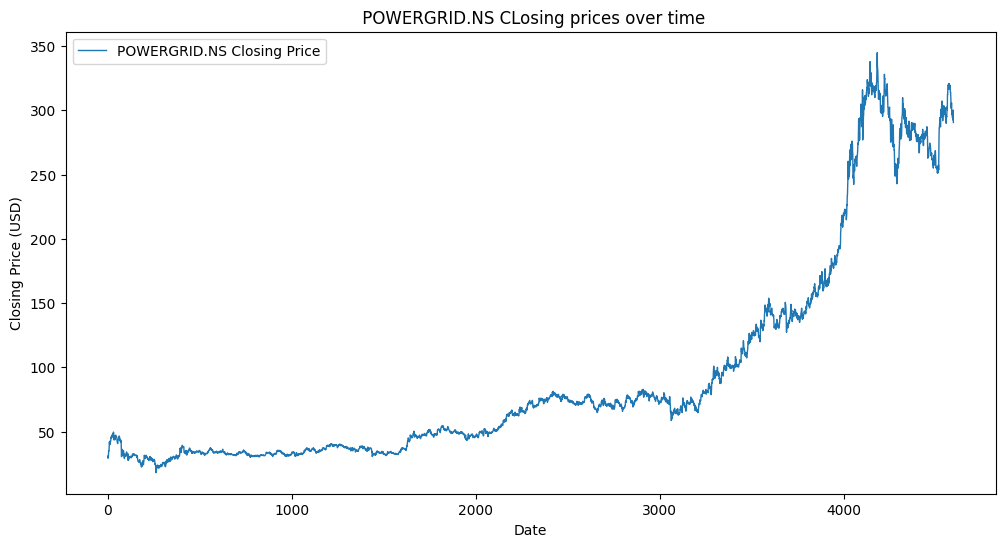

In [65]:
# For CLosing prices over time

plt.figure(figsize= (12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f' {stock} CLosing prices over time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

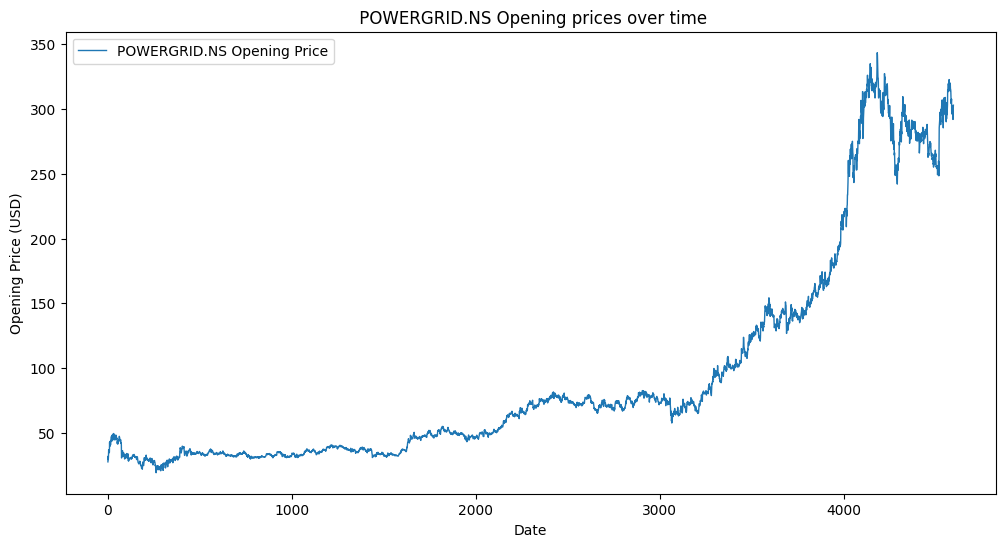

In [72]:
# For Opening prices over time

plt.figure(figsize= (12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f' {stock} Opening prices over time')
plt.xlabel('Date')
plt.ylabel('Opening Price (USD)')
plt.legend()
plt.show()

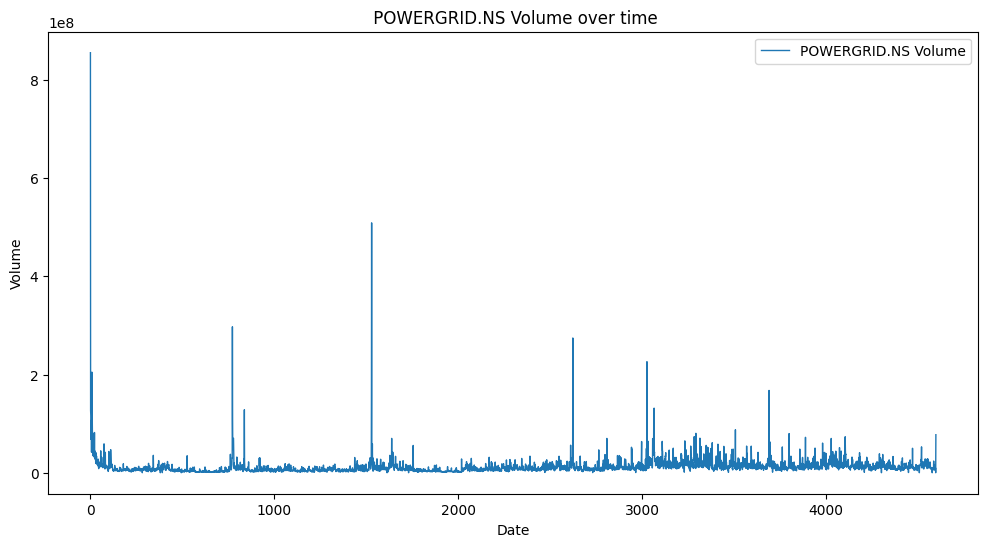

In [71]:
# For Volume over time

plt.figure(figsize= (12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 1)
plt.title(f' {stock} Volume over time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

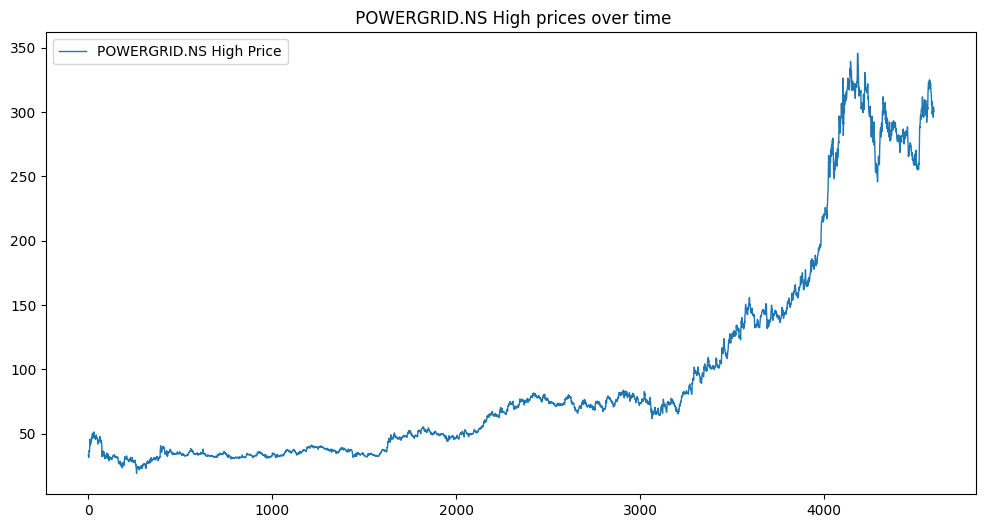

In [73]:
plt.figure(figsize= (12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 1)
plt.title(f' {stock} High prices over time')
plt.legend()
plt.show()

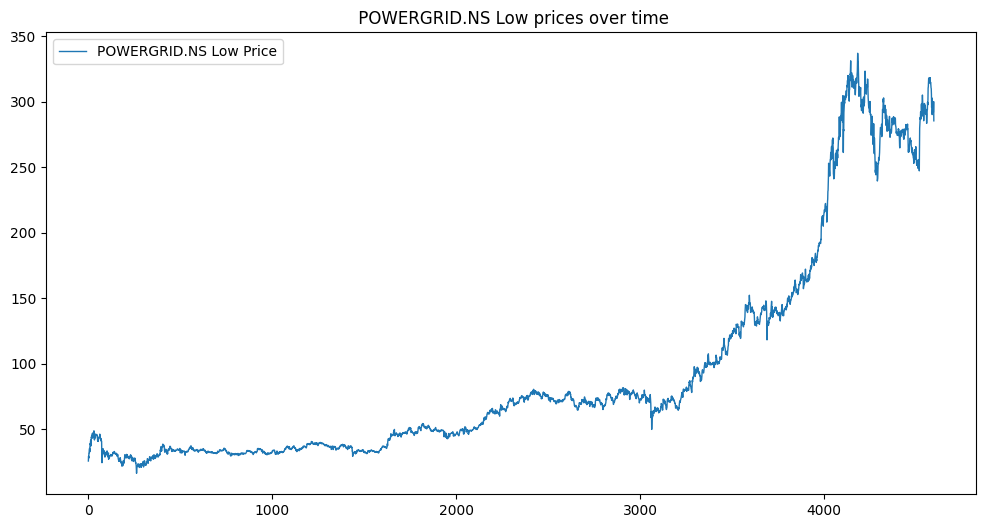

In [74]:
plt.figure(figsize= (12, 6))
plt.plot(df['Low'], label = f'{stock} Low Price', linewidth = 1)
plt.title(f' {stock} Low prices over time')
plt.legend()
plt.show()

In [77]:
# Moving Average
#[10, 20, 30, 40, 50, 60, 70, 80, 90]
# MA = (10+20+30+40+50) / 5

# moving average for last 5 days --> null null null null

temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[0:5])/5)

print(sum(temp_data[1:6])/5)

print(sum(temp_data[2:7])/5)

30.0
40.0
50.0


MA --> **Average keep moving.**

In [78]:
df01 = pd.DataFrame(temp_data)

In [79]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [82]:
# Take the rolling of the moving average of top 100

ma100 = df.Close.rolling(100).mean()
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4593,291.189631
4594,291.538061
4595,291.964964
4596,292.349839


In [84]:
# Take the rolling of the moving average of top 200

ma200 = df.Close.rolling(200).mean()
ma200

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4593,282.389426
4594,282.442015
4595,282.548582
4596,282.664590


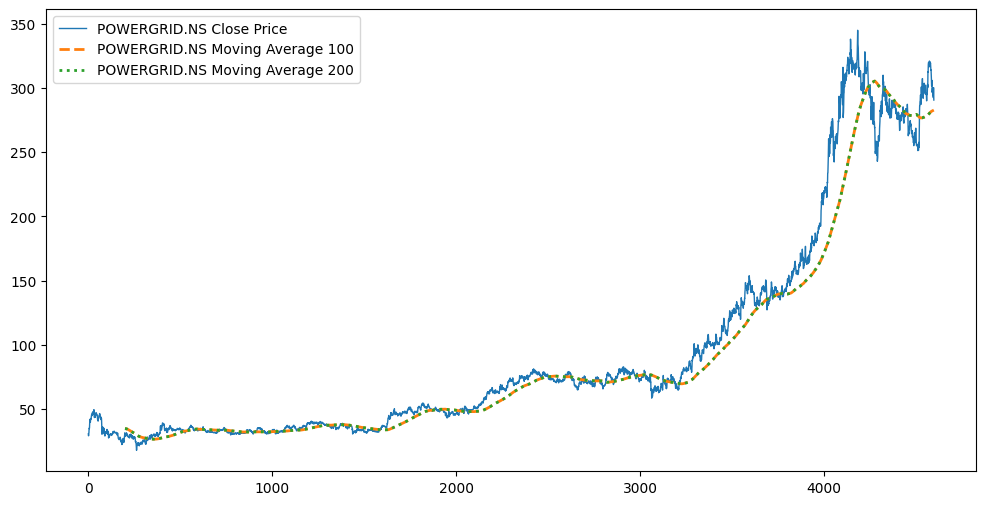

In [95]:
plt.figure(figsize= (12, 6))

plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving Average 100', linewidth = 2, linestyle = '--')
plt.plot(ma200, label = f'{stock} Moving Average 200', linewidth = 2, linestyle = ':')
plt.legend()
plt.show()

## Predict the next 30 days stock.

Using LSTM  (RNN is also another alternative to the LSTM)


In [96]:
# Exponentional Moving Average

ema100 = df.Close.ewm(span=100, adjust=False).mean()


In [97]:
ema200 = df['Close'].ewm(span=100, adjust=False).mean()


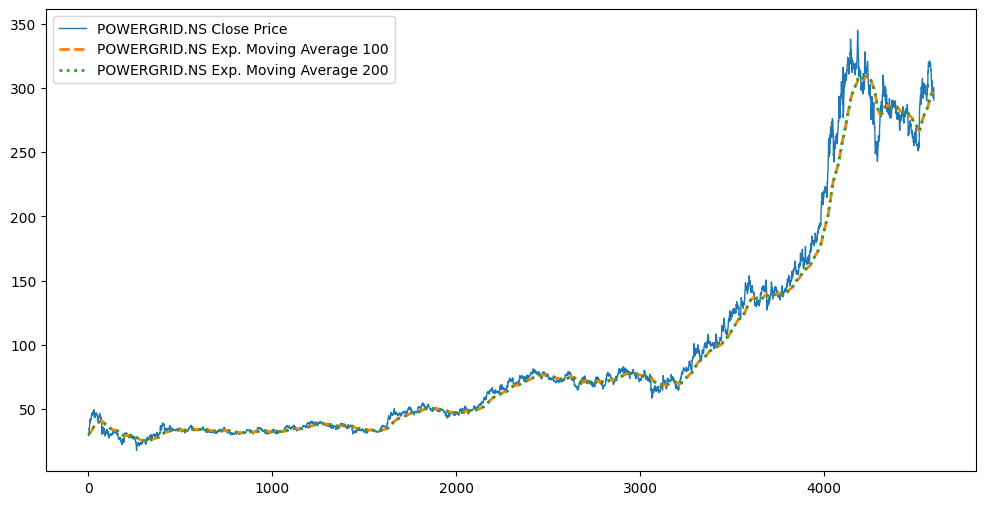

In [98]:
plt.figure(figsize= (12, 6))

plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100', linewidth = 2, linestyle = '--')
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200', linewidth = 2, linestyle = ':')
plt.legend()
plt.show()

Both plots are Almost similair.

WHY LSTM over RNN ?
-  RNN memory is low, so it can overflow.

In [100]:
# Training & Testing
data_training = pd.DataFrame(df['Close'][0: int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [101]:
data_training.shape

(3218, 1)

In [102]:
data_testing.shape

(1380, 1)

**These values  are continuous, So we have to get them into a one range.**

In [103]:
# To do that
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [104]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.19808604],
       [0.1737183 ],
       [0.20447389],
       ...,
       [0.83405551],
       [0.82988996],
       [0.82187868]])

In [106]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [107]:
x_train.shape

(3118, 100, 1)

In [108]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential


LSTM Input --> 3D (batch_size, time_steps, seq_len)
  
  LSTM 2D OR 3D
  -  2D --> (batch_size, units)
  -  3D --> (batch_size, time_steps, units)



In [109]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [110]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 5)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 48s 408ms/step - loss: 0.0059
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 33s 330ms/step - loss: 0.0050
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 50s 421ms/step - loss: 0.0050
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 355ms/step - loss: 0.0046
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 46s 405ms/step - loss: 0.0042


In [119]:
past_100_days = data_training.tail(100)

final_df = pd.concat([past_100_days, data_testing], ignore_index = True)

-  **append** method in DataFrame had deprecated.

-  Instead use **concat** method to combine the past_100_days and data_training.

In [120]:
final_df.head()

Ticker,POWERGRID.NS
0,69.542755
1,67.631332
2,66.390968
3,66.167274
4,64.865906


In [121]:
input_data = scaler.fit_transform(final_df)

In [122]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

In [123]:
x_test.shape

(1380, 100, 1)

In [124]:
y_predicted = model.predict(x_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step


In [125]:
y_predicted.shape

(1380, 1)

In [127]:
scaler.scale_

array([0.00357077])

In [129]:
scaler_factor = 1/ 0.0035166
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor